In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import datetime

# Training set analysis

In [2]:
data_path = '../../data/01_processed/pan20-authorship-verification-training-large.jsonl'

data_file_size = os.path.getsize(data_path)
data = []

with open(data_path, 'r') as f:
    with tqdm(total=data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(data)} items.")

Loading data: 100%|██████████| 12.0G/12.0G [00:35<00:00, 340MB/s]


Successfully loaded 275565 items.


Load the data into the pandas dataframe

In [3]:
data_df = pd.DataFrame(data)
data_df.drop(columns=['fandoms'], inplace=True)
print(data_df.head(10))

                                     id  \
0  6b177179-72d2-5c87-ba2e-7678ae8c1db2   
1  80ff51a1-8f2b-507e-bece-e0a187f26a19   
2  b6492f44-4d7b-51d2-a6c8-fdfaf62868e4   
3  c502df34-8c2e-5a86-9555-cdcf0b03f189   
4  653cfc2d-5e82-5afa-87b1-c5b793441483   
5  7284fa07-32de-5ab8-a5b3-5b040bb59898   
6  ec4ca49c-5975-5b25-8f9b-bfc774775ce2   
7  7b312e06-d0d3-503b-ab52-997f99dd29bb   
8  2618e80d-1150-5d31-90ff-818d28e40724   
9  531e63a7-5db2-5ba8-9737-ad2ceab0265a   

                                                pair  
0  ["Alright..." We looked at the crowd of wide-e...  
1  [I had a rude awakening when a goblin threw so...  
2  ["The offer still stands." She stopped breathi...  
3  ["Yeah." "Just pretend you"ve put on the recor...  
4  ["Paloma just went "aww" like it could actuall...  
5  ["Good, honey, how are you?" "Oh, I"m... Deali...  
6  ["Something wrong?" he ventures timidly. "I......  
7  [Down, down they tumble down the hole, filled ...  
8  ["Well, why don"t you hold o

In [4]:
data_truth_path = '../../data/01_processed/pan20-authorship-verification-training-large-truth.jsonl'

data_truth_file_size = os.path.getsize(data_truth_path)
data_truth = []

with open(data_truth_path, 'r') as f:
    with tqdm(total=data_truth_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            data_truth.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(data_truth)} items.")

Loading data: 100%|██████████| 26.4M/26.4M [00:01<00:00, 25.3MB/s]


Successfully loaded 275565 items.


Load the data into pandas dataframe

In [5]:
data_truth_df = pd.DataFrame(data_truth)
data_truth_df.drop(columns=['authors'], inplace=True)
print(data_truth_df.head())

                                     id  same
0  6b177179-72d2-5c87-ba2e-7678ae8c1db2  True
1  80ff51a1-8f2b-507e-bece-e0a187f26a19  True
2  b6492f44-4d7b-51d2-a6c8-fdfaf62868e4  True
3  c502df34-8c2e-5a86-9555-cdcf0b03f189  True
4  653cfc2d-5e82-5afa-87b1-c5b793441483  True


Combine the dataframes for evaluation

In [6]:
data_full_df = pd.merge(data_df, data_truth_df, on='id')
print(data_full_df.head())

                                     id  \
0  6b177179-72d2-5c87-ba2e-7678ae8c1db2   
1  80ff51a1-8f2b-507e-bece-e0a187f26a19   
2  b6492f44-4d7b-51d2-a6c8-fdfaf62868e4   
3  c502df34-8c2e-5a86-9555-cdcf0b03f189   
4  653cfc2d-5e82-5afa-87b1-c5b793441483   

                                                pair  same  
0  ["Alright..." We looked at the crowd of wide-e...  True  
1  [I had a rude awakening when a goblin threw so...  True  
2  ["The offer still stands." She stopped breathi...  True  
3  ["Yeah." "Just pretend you"ve put on the recor...  True  
4  ["Paloma just went "aww" like it could actuall...  True  


Number of instances
data_full_df.shape[0]

In [7]:
len(data_full_df)

275801

Check for duplicates of pairs of text

In [8]:
pair_tuples = data_full_df['pair'].apply(frozenset)
any_duplicates = pair_tuples.duplicated().sum()
any_duplicates

246

check for duplicates of texts

In [9]:
all_texts = data_df['pair'].explode()
text_counts = all_texts.value_counts()
text_counts.values

array([12, 10,  8, ...,  1,  1,  1])

The counts of each category for both datasets

In [10]:
label_counts = data_full_df["same"].value_counts()
label_counts

same
True     148014
False    127787
Name: count, dtype: int64

Longest text

In [11]:
all_texts_list = list(all_texts.values)
all_texts_list.sort(reverse=True, key=len)
len(all_texts_list[0])

943947

Shortest text

In [12]:
len(all_texts_list[-1])

20355

Median text length

In [13]:
all_texts_length_list = [len(text) for text in all_texts_list]
median_texts_length = np.median(all_texts_length_list)
median_texts_length

21285.0

Average text length

In [14]:
average_texts_length = np.average(all_texts_length_list)
average_texts_length 

21427.815838368442

create text length graph

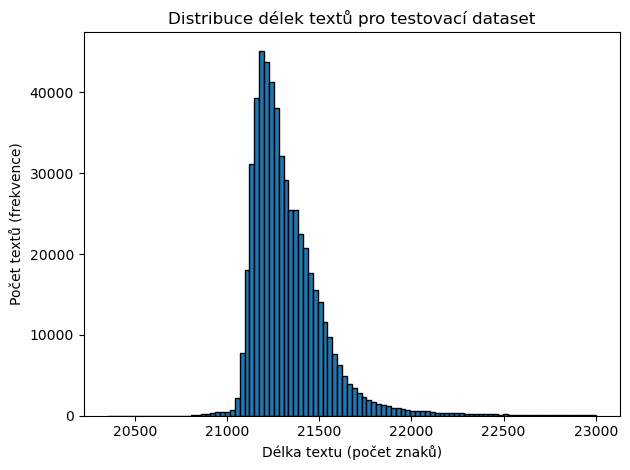

In [15]:
limited_lengths_list = [length for length in all_texts_length_list if length > 15000 and length < 23000]
plt.hist(limited_lengths_list, bins=100, edgecolor='black')

plt.title('Distribuce délek textů pro testovací dataset')
plt.xlabel('Délka textu (počet znaků)')
plt.ylabel('Počet textů (frekvence)')

plt.tight_layout()

today = datetime.date.today()
date_string = today.strftime("%Y%m%d%m")

plt.savefig(f'../../data/04_reporting/{date_string}_JP-train_dataset_text_length_histogram.png')
plt.show()